In [1]:
import pandas as pd
dataset = pd.read_csv("41100080.csv")

In [ ]:
drop_cols = ["UOM_ID", "SCALAR_FACTOR", "SCALAR_ID", "VECTOR", "SYMBOL", "TERMINATED", "DECIMALS"]
dataset.drop(labels=drop_cols, axis="columns", inplace=True)

: 

In [ ]:
dataset = dataset[~(dataset.STATUS == "F")]
dataset.head()

,REF_DATE,GEO,DGUID,Indigenous identity,Age group,Gender,Overall health,Housing - Needs repairs,Persons per room (crowding),Statistics,UOM,COORDINATE,VALUE,STATUS
0,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",Number of persons,Persons,1.1.1.1.1.1.1.1,1077810.0,NaN
1,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",Percent,Percent,1.1.1.1.1.1.1.2,100.0,NaN
2,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",Low 95% confidence interval,Percent,1.1.1.1.1.1.1.3,100.0,NaN
3,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",High 95% confidence interval,Percent,1.1.1.1.1.1.1.4,100.0,NaN
4,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs",One person or fewer per room,Number of persons,Persons,1.1.1.1.1.1.2.1,999250.0,NaN


: 

Gender,Men+,"Total, gender",Women+
Indigenous identity,,,
First Nations (North American Indian),17228.700624,25436.230110,18011.895816
"First Nations (North American Indian), Registered or Treaty Indian",14324.056162,20242.062600,15323.823884
"First Nations (North American Indian), not a Registered or Treaty Indian",12248.429752,15215.048780,11339.705263
Inuk (Inuit),1717.825371,2465.498252,1975.410072
Métis,19493.959505,27269.959211,18979.837893
"Total, Indigenous identity",21333.195084,32205.236314,22103.055176


Gender,Indigenous identity,Men+,"Total, gender",Women+
0,First Nations (North American Indian),17228.700624,25436.230110,18011.895816
1,"First Nations (North American Indian), Registe...",14324.056162,20242.062600,15323.823884
2,"First Nations (North American Indian), not a R...",12248.429752,15215.048780,11339.705263
3,Inuk (Inuit),1717.825371,2465.498252,1975.410072
4,Métis,19493.959505,27269.959211,18979.837893
5,"Total, Indigenous identity",21333.195084,32205.236314,22103.055176


<Axes: xlabel='VALUE', ylabel='Indigenous identity'>

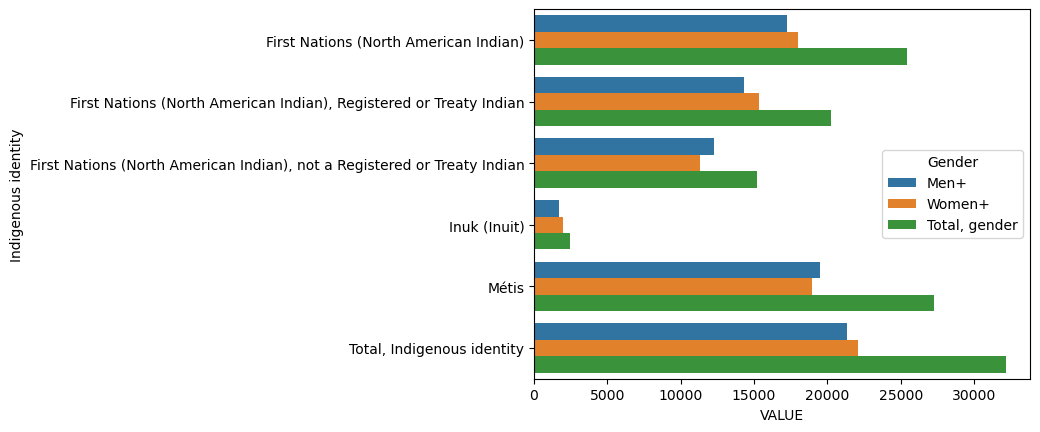

: 

In [ ]:
import seaborn as sb

no_of_persons = dataset[dataset.Statistics == "Number of persons"]
id_vs_gender = no_of_persons.pivot_table(index=["Indigenous identity"], columns=["Gender"], values="VALUE")
id_vs_gender = id_vs_gender.drop(index="Indigenous responses not included elsewhere")
display(id_vs_gender)

# id_vs_gender = no_of_persons.pivot_table(index=["Indigenous identity", "Gender"], values="VALUE")

# indigenous_identity = no_of_persons["Indigenous identity"].unique()
# gender_order = ["Men+", "Women+", "Total, gender"]
# new_gender_index = pd.MultiIndex.from_product([indigenous_identity, gender_order], names=["Indigenous identity", "Gender"])
# id_vs_gender = id_vs_gender.reindex(new_gender_index)

id_vs_gender_reset = id_vs_gender.reset_index()
id_vs_gender_long = id_vs_gender_reset.melt(
    id_vars="Indigenous identity",
    value_vars=["Men+", "Women+", "Total, gender"],
    var_name="Gender",
    value_name="VALUE"
)

df_json = id_vs_gender_reset.rename(columns={
    "Indigenous identity": "identity",
    "Men+": "men",
    "Women+": "women",
    "Total, gender": "total"
})

display(id_vs_gender_reset)

sb.barplot(data=id_vs_gender_long, y="Indigenous identity", x="VALUE", hue="Gender")

In [4]:
import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 1, figsize=(14, 24))

overall_health = dataset[(dataset["Overall health"] != "Total, self-perceived general health") &
                         (dataset["Overall health"] != "Total, self-perceived mental health")]

health_general = overall_health[overall_health["Overall health"].str.match("^Self-perceived general")]
health_mental = pd.concat([overall_health, health_general]).drop_duplicates(keep=False)
health_general["Overall health"] = health_general["Overall health"].str.replace("Self-perceived general health, ", "").str.rstrip()
health_mental["Overall health"] = health_mental["Overall health"].str.replace("Self-perceived mental health, ", "").str.rstrip()

indigenous_identity = overall_health["Indigenous identity"].unique()
health_order = ["excellent", "excellent or very good", "very good", "good", "fair or poor"]
ordered_health_index = pd.MultiIndex.from_product([indigenous_identity, health_order], names=["Indigenous identity", "Overall health"])

id_vs_health_general = health_general.pivot_table(index=["Indigenous identity"], columns=["Overall health"], values="VALUE")
id_vs_health_mental = health_mental.pivot_table(index=["Indigenous identity"], columns=["Overall health"], values="VALUE")
# id_vs_health_general = id_vs_health_general.reindex(ordered_health_index)
# id_vs_health_mental = id_vs_health_mental.reindex(ordered_health_index)
table = pd.concat([id_vs_health_general, id_vs_health_mental], keys=["general", "mental"])

res = {}
for category, group in table.groupby(level=0):
    records = group.reset_index(level=1).to_dict(orient="records")
    res[category] = records

display(res)


# plot_general = sb.barplot(data=id_vs_health_general, y="Indigenous identity", x="VALUE", hue="Overall health", hue_order= health_order, ax=axes[0])
# axes[0].set_title("Self-perceived general health")
# plot_general.legend_.set_title("")

# plot_mental = sb.barplot(data=id_vs_health_mental, y="Indigenous identity", x="VALUE", hue="Overall health", ax=axes[1])
# axes[1].set_title("Self-perceived mental health")
# plot_mental.legend_.set_title("")

# plt.show()

{'general': [{'Indigenous identity': 'First Nations (North American Indian)',
   'excellent': 2505.327638190955,
   'excellent or very good': 4075.8641908212558,
   'fair or poor': 3240.763537300922,
   'good': 3605.780142764439,
   'very good': 3422.8234762979687},
  {'Indigenous identity': 'First Nations (North American Indian), Registered or Treaty Indian',
   'excellent': 2101.1306532663316,
   'excellent or very good': 3173.0675527756057,
   'fair or poor': 2580.3976629766294,
   'good': 3119.5857279693487,
   'very good': 2892.610847457627},
  {'Indigenous identity': 'First Nations (North American Indian), not a Registered or Treaty Indian',
   'excellent': 1942.2874074074073,
   'excellent or very good': 2861.546727549467,
   'fair or poor': 2557.061951219512,
   'good': 2500.2403880070547,
   'very good': 2607.990744920993},
  {'Indigenous identity': 'Inuk (Inuit)',
   'excellent': 234.95,
   'excellent or very good': 379.4990412979351,
   'fair or poor': 275.33691099476437,
  

<Axes: xlabel='VALUE', ylabel='Indigenous identity'>

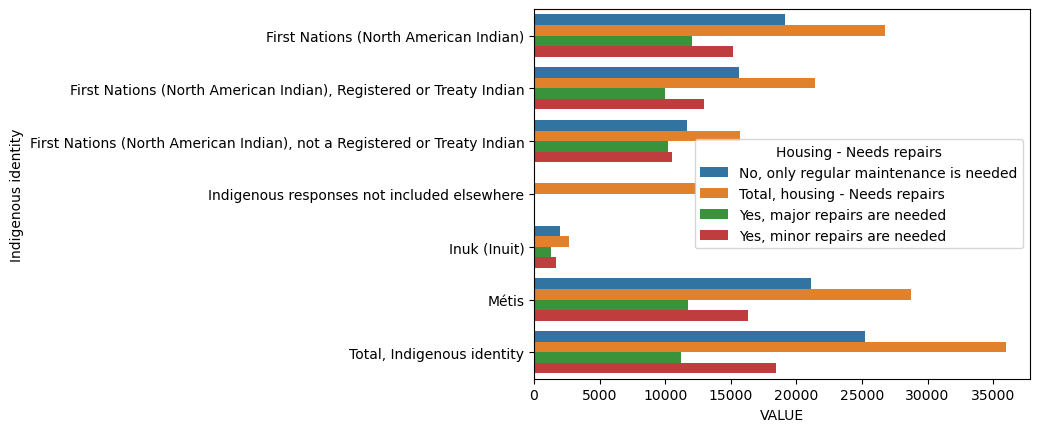

: 

In [ ]:
housings = no_of_persons.pivot_table(index=["Indigenous identity", "Housing - Needs repairs"], values="VALUE")

# housing_new_index = {
#     "No, only regular maintenance is needed": "No - Just needs regular maintenance",
#     "Total, housing - Needs repairs": "Total - Needs repairs",
#     "Yes, major repairs are needed": "Yes - Needs major repairs",
#     "Yes, minor repairs are needed": "Yes - Needs minor repairs"
# }
# mapped_index = housings.index.get_level_values("Housing - Needs repairs").map(housing_new_index)
# new_index = housings.index.set_levels(mapped_index, level="Housing - Needs repairs")
# display(mapped_index)

sb.barplot(data=housings, x="VALUE", y="Indigenous identity", hue="Housing - Needs repairs")

In [70]:
general_table = health_general.pivot_table(index=["Indigenous identity", "Overall health"], columns=["Age group"], values="VALUE")

drop_age = ["25 to 54 years"]
drop_identity = ["First Nations (North American Indian), Registered or Treaty Indian",
                 "First Nations (North American Indian), not a Registered or Treaty Indian"]

general_table.drop(columns=drop_age, index=drop_identity, inplace=True)

mental_table = health_mental.pivot_table(index=["Indigenous identity", "Overall health"], columns=["Age group"], values="VALUE")
mental_table.drop(columns=drop_age, index=drop_identity, inplace=True)

# new_health_level = health_vs_age.index.levels[1].str.replace("Self-perceived general health, ", "general-")
# new_health_level = new_health_level.str.replace("Self-perceived mental health, ", "mental-")

# for old_label , new_grade in grade_map.items():
#     new_health_level = new_health_level.str.replace(fr"{old_label}\s*$", new_grade, regex=True)
# health_vs_age.index = health_vs_age.index.set_levels(new_health_level, level=1)

table = pd.concat([general_table, mental_table], keys=["general", "mental"])

age_map = {
    "15 to 24 years": "15_24",
    "25 to 34 years": "25_34",
    "35 to 44 years": "35_44",
    "45 to 54 years": "45_54",
    "55 years and over": "55_over",
    "Total, 15 years and over": "total"
}
table.rename(columns=age_map, inplace=True)

table.index.names = ["type", "identity", "health_status"]
table_flat = table.reset_index()

grade_map = {
    "excellent": "A",
    "excellent or very good": "B_plus",
    "very good": "B",
    "good": "C",
    "fair or poor": "F"
}
table_flat["health_status"] = table_flat["health_status"].str.strip().map(grade_map)
# table_result = {
#     "general": table_flat[table_flat["type"] == "general"].drop(columns=["type"]).to_dict(orient="records"),
#     "mental": table_flat[table_flat["type"] == "mental"].drop(columns=["type"]).to_dict(orient="records")
# }

display(table_flat.to_dict(orient="records"))

[{'type': 'general',
  'identity': 'First Nations (North American Indian)',
  'health_status': 'A',
  '15_24': 1634.9714285714285,
  '25_34': 2157.0,
  '35_44': 1913.65625,
  '45_54': 1789.075,
  '55_over': 1728.8333333333333,
  'total': 3021.242965779468},
 {'type': 'general',
  'identity': 'First Nations (North American Indian)',
  'health_status': 'B_plus',
  '15_24': 2150.140338983051,
  '25_34': 3121.8218309859158,
  '35_44': 3053.788181818182,
  '45_54': 2910.825252525253,
  '55_over': 3004.099507389162,
  'total': 6082.91618852459},
 {'type': 'general',
  'identity': 'First Nations (North American Indian)',
  'health_status': 'F',
  '15_24': 1449.5727272727274,
  '25_34': 2908.6971014492756,
  '35_44': 1985.9830188679246,
  '45_54': 2615.3089552238807,
  '55_over': 2392.882191780822,
  'total': 4461.331067961165},
 {'type': 'general',
  'identity': 'First Nations (North American Indian)',
  'health_status': 'C',
  '15_24': 1793.8775330396477,
  '25_34': 2853.1632,
  '35_44': 220